In [1]:
!kaggle datasets download -d ananthu017/emotion-detection-fer

Dataset URL: https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer
License(s): CC0-1.0
 97% 63.0M/65.2M [00:00<00:00, 127MB/s]
100% 65.2M/65.2M [00:00<00:00, 107MB/s]


In [2]:
!unzip /content/emotion-detection-fer.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/im37.png      
  inflating: train/sad/im370.png     
  inflating: train/sad/im3700.png    
  inflating: train/sad/im3701.png    
  inflating: train/sad/im3702.png    
  inflating: train/sad/im3703.png    
  inflating: train/sad/im3704.png    
  inflating: train/sad/im3705.png    
  inflating: train/sad/im3706.png    
  inflating: train/sad/im3707.png    
  inflating: train/sad/im3708.png    
  inflating: train/sad/im3709.png    
  inflating: train/sad/im371.png     
  inflating: train/sad/im3710.png    
  inflating: train/sad/im3711.png    
  inflating: train/sad/im3712.png    
  inflating: train/sad/im3713.png    
  inflating: train/sad/im3714.png    
  inflating: train/sad/im3715.png    
  inflating: train/sad/im3716.png    
  inflating: train/sad/im3717.png    
  inflating: train/sad/im3718.png    
  inflating: train/sad/im3719.png    
  inflating: train/sad/im372.png     
  inflating: train/sad/im3720.png    

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
tf.random.set_seed (42)

train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_dir = '/content/train'
test_dir = '/content/test'

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(48,48),
                                               class_mode='categorical',
                                               )

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(48,48),
                                               class_mode='categorical',
                                              )



Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
def view_image(target_dir, target_class):
  target_folder = target_dir + '/' + target_class
  random_image = random.sample(os.listdir(target_folder),1)
  img = mpimg.imread(target_folder + '/' + random_image[0])
  plt.imshow(img,cmap='gray')
  plt.title(target_class)
  plt.axis('off')

  print(f'Image shape: {img.shape}')

Image shape: (48, 48)


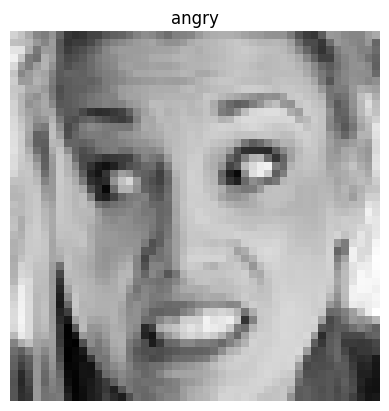

In [5]:
img = view_image(target_dir = '/content/train',
                        target_class = 'angry')

In [6]:
augmented_data = ImageDataGenerator(
                            rescale=1/255.0,
                            rotation_range=20,
                            zoom_range=0.1,
                            shear_range=0.1,
                            height_shift_range=0.1,
                            width_shift_range=0.1,
                            horizontal_flip=True,

)

test_datagen = ImageDataGenerator(rescale=1/255.0)
train_data_generator = augmented_data.flow_from_directory(train_dir,
                                                         batch_size=32,
                                                         class_mode='categorical',
                                                         target_size=(48,48),
                                                         shuffle = True,

)


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical',
    shuffle = False
)



Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [7]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                     classes = np.unique(train_data_generator.classes),
                                                         y = train_data_generator.classes)

class_weights = dict(enumerate(class_weights))

class_weights


{0: 1.0266046844269623,
 1: 9.406618610747051,
 2: 1.0010460615781582,
 3: 0.5684387684387684,
 4: 0.8260394187886635,
 5: 0.8491274770777877,
 6: 1.293372978330405}

In [8]:
model1= tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48,48,3)),
    tf.keras.layers.Conv2D(32,3,activation='relu',padding='same',kernel_initializer='he_normal'),

    tf.keras.layers.Conv2D(64,3,activation='relu',padding='same',kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128,5,activation='relu',padding='same',kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(512,3,activation='relu',padding='same',kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(512,3,activation='relu',padding='same',kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(7,activation='softmax')
])

In [9]:
import tensorflow.keras.backend as K

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_true = K.clip(y_true, epsilon, 1. - epsilon)
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed


In [10]:
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,min_lr=1e-6, patience=3)
callback = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights = True)
model1.compile(
    loss = focal_loss(gamma=2., alpha=0.25),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
history1 = model1.fit(train_data_generator,
                      epochs=60,
                      validation_data=test_data,
                      class_weight=class_weights,
                      callbacks=[callback,lr_schedule])

Epoch 1/60


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.1730 - loss: 0.4672 - val_accuracy: 0.1294 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 2/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.2044 - loss: 0.3545 - val_accuracy: 0.2623 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 3/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.2743 - loss: 0.3206 - val_accuracy: 0.3537 - val_loss: 0.2840 - learning_rate: 0.0010
Epoch 4/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.3388 - loss: 0.2868 - val_accuracy: 0.4334 - val_loss: 0.2419 - learning_rate: 0.0010
Epoch 5/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.3898 - loss: 0.2644 - val_accuracy: 0.4804 - val_loss: 0.2215 - learning_rate: 0.0010
Epoch 6/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.4354 - loss: 0.2398 - val_accuracy: 0.4358 - val_loss: 0.2319 - learning_rate: 0.0010
Epoch 7/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.4413 - loss: 0.2366

In [11]:
model1.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6108 - loss: 0.1460


[0.1366027295589447, 0.6497631669044495]

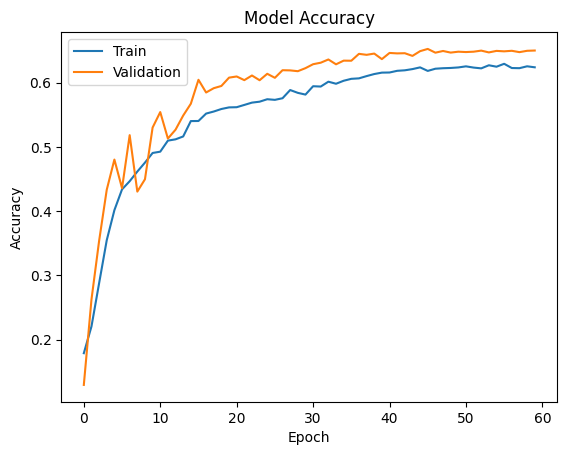

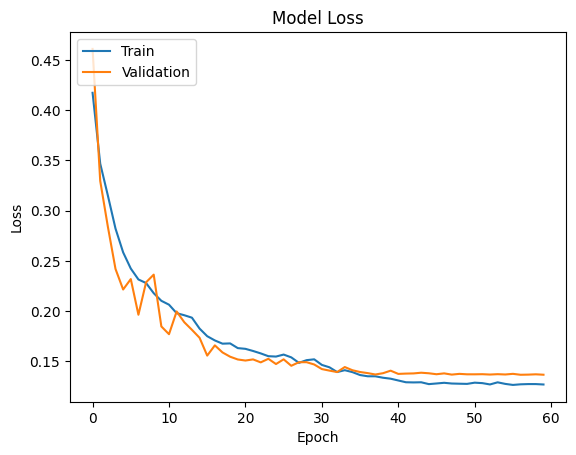

In [12]:
import matplotlib.pyplot as plt
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


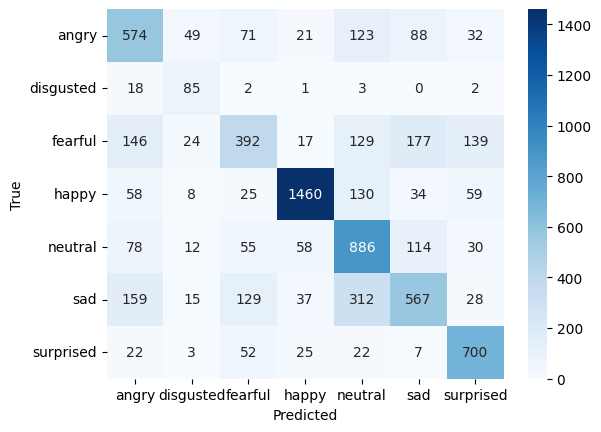

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_pred = model1.predict(test_data)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true,y_pred_classes)
class_labels = list(test_data.class_indices.keys())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [14]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(48, 48, 3),
    weights="imagenet"
)
base_model.trainable = False

model2 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

<ipython-input-14-fa8a21b76d10>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,min_lr=1e-6, patience=3)
callback = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights = True)
model2.compile(
    loss =  focal_loss(gamma=2., alpha=0.25),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
history2= model2.fit(train_data_generator,
                      epochs=25,
                      validation_data=test_data,
                      class_weight=class_weights,
                      callbacks=[callback,lr_schedule])

Epoch 1/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 54ms/step - accuracy: 0.2239 - loss: 0.4958 - val_accuracy: 0.3128 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.2629 - loss: 0.3399 - val_accuracy: 0.3339 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.2774 - loss: 0.3203 - val_accuracy: 0.2612 - val_loss: 0.3448 - learning_rate: 0.0010
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.2780 - loss: 0.3187 - val_accuracy: 0.3302 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.2835 - loss: 0.3180 - val_accuracy: 0.3047 - val_loss: 0.2983 - learning_rate: 0.0010
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.2962 - loss: 0.2968 - val_accuracy: 0.3364 - val_loss: 0.2898 - learning_rate: 5.0000e-04
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.3073

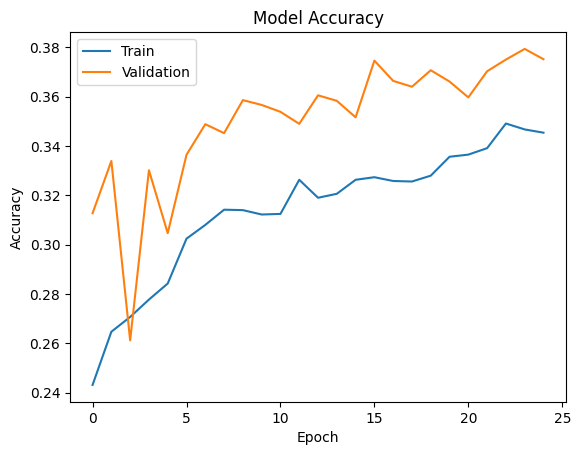

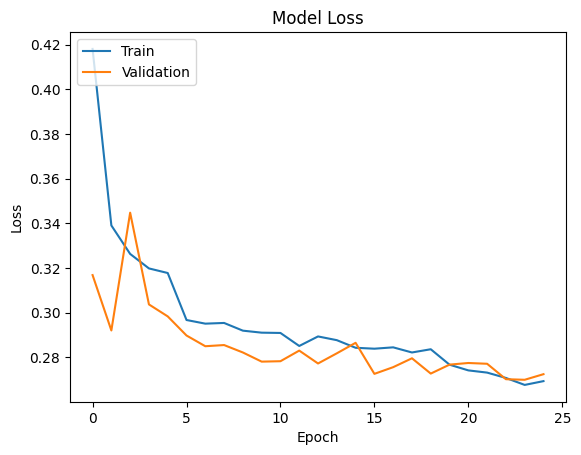

In [16]:
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [17]:
model2.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3260 - loss: 0.2854


[0.26994234323501587, 0.3793535828590393]

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


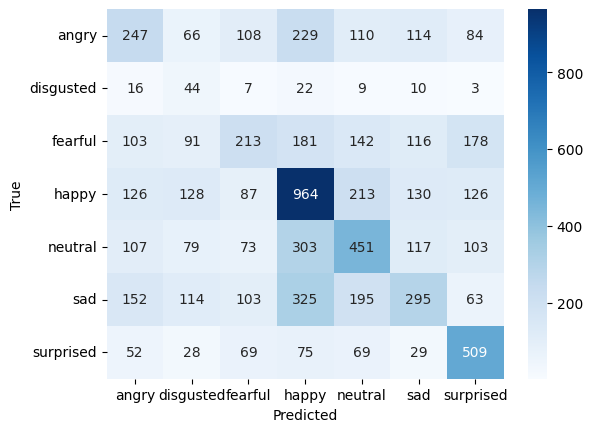

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_pred = model2.predict(test_data)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true,y_pred_classes)
class_labels = list(test_data.class_indices.keys())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [19]:
import tensorflow as tf

# Define the inception model
def inception_block(inputs, oxo, txt_red, txt, fxf_red, fxf):
    one_by_one = tf.keras.layers.Conv2D(oxo, 1, activation='relu', kernel_initializer='he_normal', padding='same')(inputs)

    three_by_three_red = tf.keras.layers.Conv2D(txt_red, 1, activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    three_by_three = tf.keras.layers.Conv2D(txt_red, 3, activation='relu', kernel_initializer='he_normal', padding='same')(three_by_three_red)

    five_by_five_red = tf.keras.layers.Conv2D(fxf_red, 1, activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    five_by_five = tf.keras.layers.Conv2D(fxf_red, 5, activation='relu', kernel_initializer='he_normal', padding='same')(five_by_five_red)

    max_pool = tf.keras.layers.MaxPooling2D(3, strides=1, padding='same')(inputs)
    max_pool_1 = tf.keras.layers.Conv2D(oxo, 1, activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    concat = tf.keras.layers.Concatenate()([one_by_one, three_by_three, five_by_five, max_pool_1])
    return concat

def make_inception_model(shape, n_classes, activation='softmax'):
    inputs = tf.keras.layers.Input(shape=shape)
    conv_0 = tf.keras.layers.Conv2D(64, 7, activation='relu', kernel_initializer='he_normal', strides=2)(inputs)
    max_pool_0 = tf.keras.layers.MaxPooling2D(3, strides=2)(conv_0)
    batch_norm_0 = tf.keras.layers.BatchNormalization()(max_pool_0)
    conv_1 = tf.keras.layers.Conv2D(64, 1, strides=1, padding='valid', activation='relu', kernel_initializer='he_normal')(batch_norm_0)
    conv_2 = tf.keras.layers.Conv2D(192, 3, padding='same', activation='relu', kernel_initializer='he_normal', strides=1)(conv_1)
    batch_norm_1 = tf.keras.layers.BatchNormalization()(conv_2)
    max_pool_1 = tf.keras.layers.MaxPooling2D(3, strides=2, padding='same')(batch_norm_1)

    inception_0 = inception_block(max_pool_1, 64, 96, 128, 16, 32)
    inception_1 = inception_block(inception_0, 128, 128, 192, 32, 96)
    max_pool_2 = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same')(inception_1)
    inception_2 = inception_block(max_pool_2, 192, 96, 208, 16, 48)

    avg_pool_0 = tf.keras.layers.AveragePooling2D(2, strides=1, padding='valid')(inception_2)
    conv_out_0 = tf.keras.layers.Conv2D(192, 1, strides=1, padding='same', activation='relu', kernel_initializer='he_normal')(avg_pool_0)

    flattened_0 = tf.keras.layers.Flatten()(conv_out_0)
    dense_0 = tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal')(flattened_0)
    output_0 = tf.keras.layers.Dense(n_classes, activation=activation)(dense_0)

    model = tf.keras.Model(inputs=inputs, outputs=output_0)
    return model


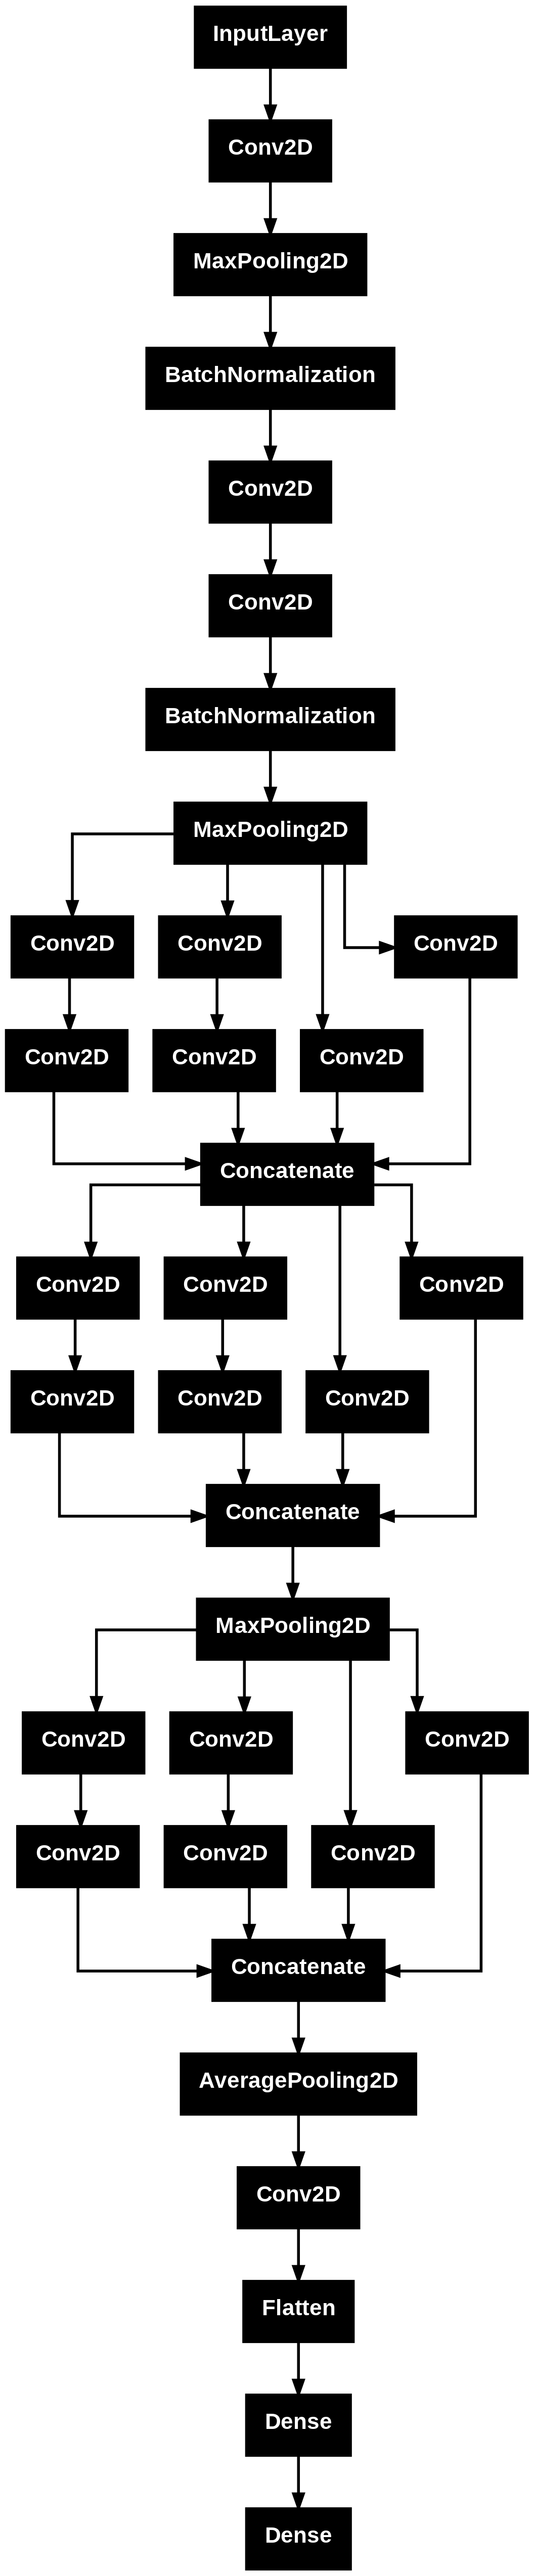

In [20]:
model = make_inception_model(shape=(48, 48, 3), n_classes=7)

tf.keras.utils.plot_model(model)

In [21]:
model = make_inception_model(shape=(48, 48, 3), n_classes=7)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,min_lr=1e-6, patience=3)
callback = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights = True)
model.compile(
    loss =  focal_loss(gamma=2., alpha=0.25),
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
history= model.fit(train_data_generator,
                      epochs=55,
                      validation_data=test_data,
                      class_weight=class_weights,
                      callbacks=[callback,lr_schedule])

Epoch 1/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - accuracy: 0.1734 - loss: 0.3914 - val_accuracy: 0.2292 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 2/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.2686 - loss: 0.3224 - val_accuracy: 0.2647 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 3/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.3313 - loss: 0.3001 - val_accuracy: 0.1623 - val_loss: 0.3572 - learning_rate: 0.0010
Epoch 4/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.3608 - loss: 0.2861 - val_accuracy: 0.3777 - val_loss: 0.2674 - learning_rate: 0.0010
Epoch 5/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.3982 - loss: 0.2670 - val_accuracy: 0.2983 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 6/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.4110 - loss: 0.2540 - val_accuracy: 0.2342 - val_loss: 0.3106 - learning_rate: 0.0010
Epoch 7/55
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.4160 - l

In [22]:
model.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5250 - loss: 0.1809


[0.16283197700977325, 0.5831707715988159]

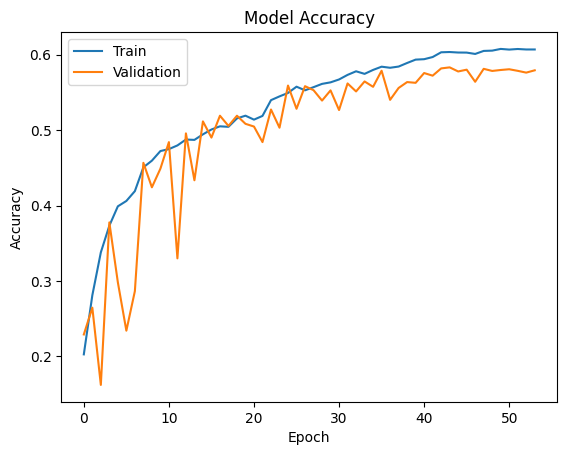

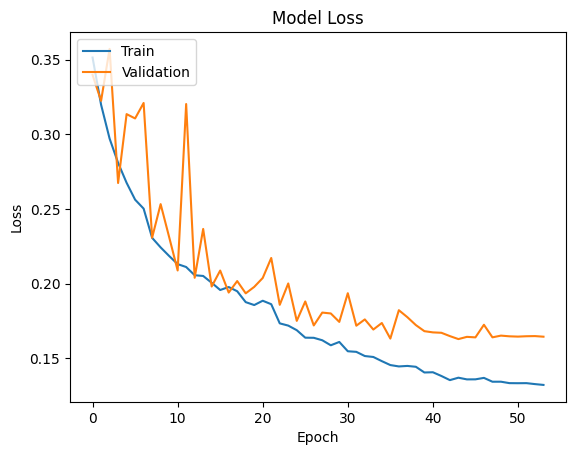

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


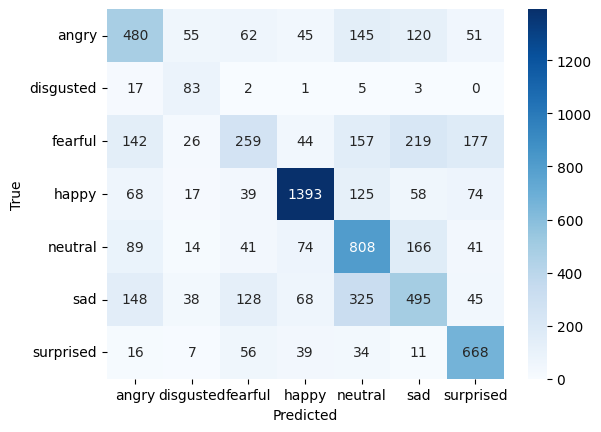

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true,y_pred_classes)
class_labels = list(test_data.class_indices.keys())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [25]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [26]:
model1.save('/content/model1.keras')

In [27]:
!mv /content/model1.keras /content/drive/MyDrive/
